In [1]:
from set_up.generic_business_case_runner import run_business_case

from assets.EL_input_data import el_parameters
from assets.OWF_input_data import owf_parameters
from assets.OnEL_input_data import onel_parameters

import ipynb.fs.defs.assets.EL_working_file as el_module
import ipynb.fs.defs.assets.OWF_working_file as owf_module
import ipynb.fs.defs.assets.OnEL_working_file as onel_module

import assets.EL_input_data as el_inputs
import assets.OWF_input_data as owf_inputs
import assets.OnEL_input_data as onel_inputs

import set_up.generic_business_case_runner as runner

from analysis.sensitivity import run_oat_sensitivity,get_base_case_values,tornado_plot
from analysis.cum_equity_debt_figure import plot_cumulative_cashflows
from analysis.scenario_analysis import run_levelized_breakdown_scenarios, plot_scenario_breakdown

Active Scenario: most_likely (Index: 1)
Active Scenario: most_likely (Index: 1)
Active Scenario: most_likely (Index: 1)
All variables saved to NSE_get_data_from_ESDL.pkl


**Sensitivity analysis**

In [2]:
# Run the sensitivity analysis, this will give 4 KPI dfs
df_proj_npv_sa, df_eq_npv_sa, df_lco_sa, df_gap_sa = run_oat_sensitivity(onel_module, runner, onel_parameters)

# View all tables
print("--- 1) PROJECT NPV SENSITIVITY ---")
display(df_proj_npv_sa.style.format(precision=2))

print("\n--- 2) EQUITY NPV SENSITIVITY ---")
display(df_eq_npv_sa.style.format(precision=2))

print("\n--- 3) LEVELIZED COST SENSITIVITY ---")
display(df_lco_sa.style.format(precision=2))

print("\n--- 4) UNPROFITABLE GAP SENSITIVITY ---")
display(df_gap_sa.style.format(precision=2))

--- 1) PROJECT NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,206.49,301.33
wacc,367.32,126.25
income_tax_rate,236.90,236.90
inflation,206.22,268.49
loan_interest_rate,236.90,236.90
loan_percentage,236.90,236.90
decommissioning_percentage,237.21,236.59
capex,343.07,130.73
opex_df,266.54,207.25



--- 2) EQUITY NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,38.71,110.37
wacc,145.20,-7.99
income_tax_rate,84.06,39.55
inflation,38.90,85.40
loan_interest_rate,66.28,57.22
loan_percentage,29.96,96.58
decommissioning_percentage,62.12,61.50
capex,140.10,-13.58
opex_df,85.06,38.53



--- 3) LEVELIZED COST SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,284.63,280.95
wacc,276.14,291.05
income_tax_rate,281.74,285.14
inflation,278.98,288.03
loan_interest_rate,282.39,284.59
loan_percentage,281.99,285.06
decommissioning_percentage,283.42,283.47
capex,273.59,293.46
opex_df,281.67,285.22



--- 4) UNPROFITABLE GAP SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-20.19,-13.88
wacc,-9.59,-26.61
income_tax_rate,-16.27,-19.66
inflation,-19.71,-16.17
loan_interest_rate,-16.92,-19.11
loan_percentage,-16.51,-19.58
decommissioning_percentage,-17.94,-17.99
capex,-8.11,-27.98
opex_df,-16.19,-19.74


Tornado graphs

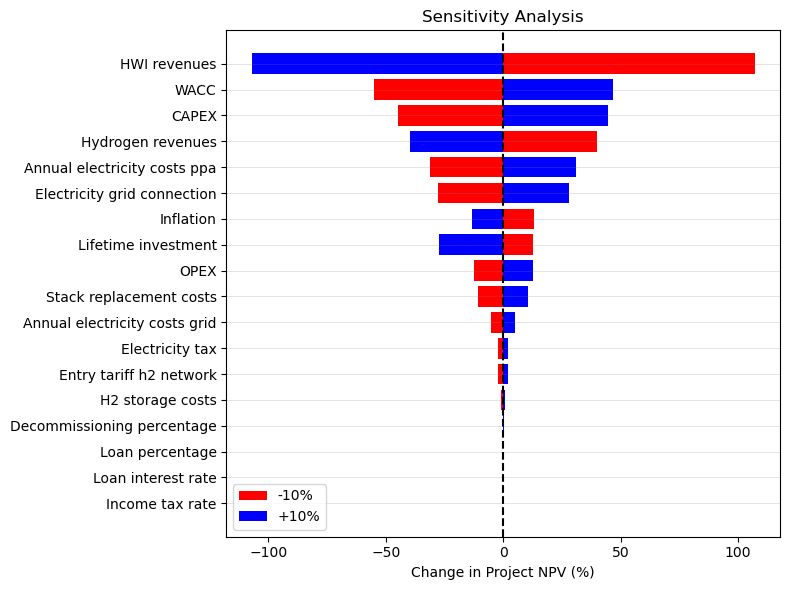

In [3]:
# First we get the base case values
owf_base_cases = get_base_case_values(owf_module, runner, owf_parameters)
el_base_cases = get_base_case_values(el_module, runner, el_parameters)
onel_base_cases = get_base_case_values(onel_module, runner, onel_parameters)

# Plot the Project NPV tornado graph 
tornado_plot(df_proj_npv_sa,onel_base_cases['Project NPV'],'Project NPV')

# Plot the Equity NPV tornado graph 
# tornado_plot(df_eq_npv_sa,el_base_cases['Equity NPV'], 'Equity NPV')

# Plot the Levelized Cost tornado graph
# tornado_plot(df_lco_sa, el_base_cases['Levelized Cost'], 'Levelized Cost')

# Plot the Unprofitable Gap tornado graph
# tornado_plot(df_gap_sa,el_base_cases['Unprofitable Gap'], 'Unprofitable Gap')

Cumulative equity and debt figure

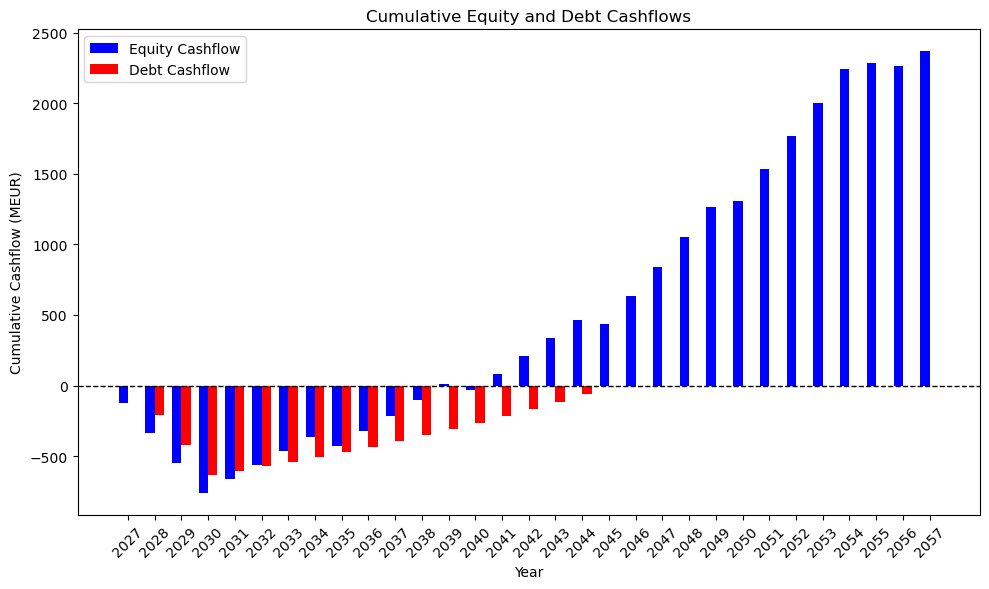

In [4]:
# Plot the graph
plot_cumulative_cashflows(onel_module, runner, onel_parameters)

**Pessimistic, most likely, optimistic scenarios**

In [5]:
# Get the df with levelized cost and revenues for all scenarios
df_analysis = run_levelized_breakdown_scenarios(runner, onel_module, onel_inputs, "onel_parameters")
display(df_analysis.style.format(precision=2))

Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


levelized cost calculations,Cost (Pessimistic),Revenue (Pessimistic),Cost (Base),Revenue (Base),Cost (Optimistic),Revenue (Optimistic)
capex,95.36,0.00,80.73,0.00,41.46,0.00
opex,27.64,0.00,22.61,0.00,16.27,0.00
purchase_electricity_ppa,73.28,0.00,56.07,0.00,55.45,0.00
purchase_electricity_grid,12.96,0.00,9.43,0.00,8.10,0.00
electricity_grid_connection,49.10,0.00,50.22,0.00,52.58,0.00
h2_storage_costs,0.96,0.00,1.38,0.00,1.59,0.00
entry_tariff_h2_network,3.60,0.00,3.68,0.00,3.85,0.00
electricity_tax,3.90,0.00,3.99,0.00,4.18,0.00
stack_replacement,20.66,0.00,19.08,0.00,14.07,0.00
decommissioning,0.40,0.00,0.24,0.00,0.18,0.00


Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


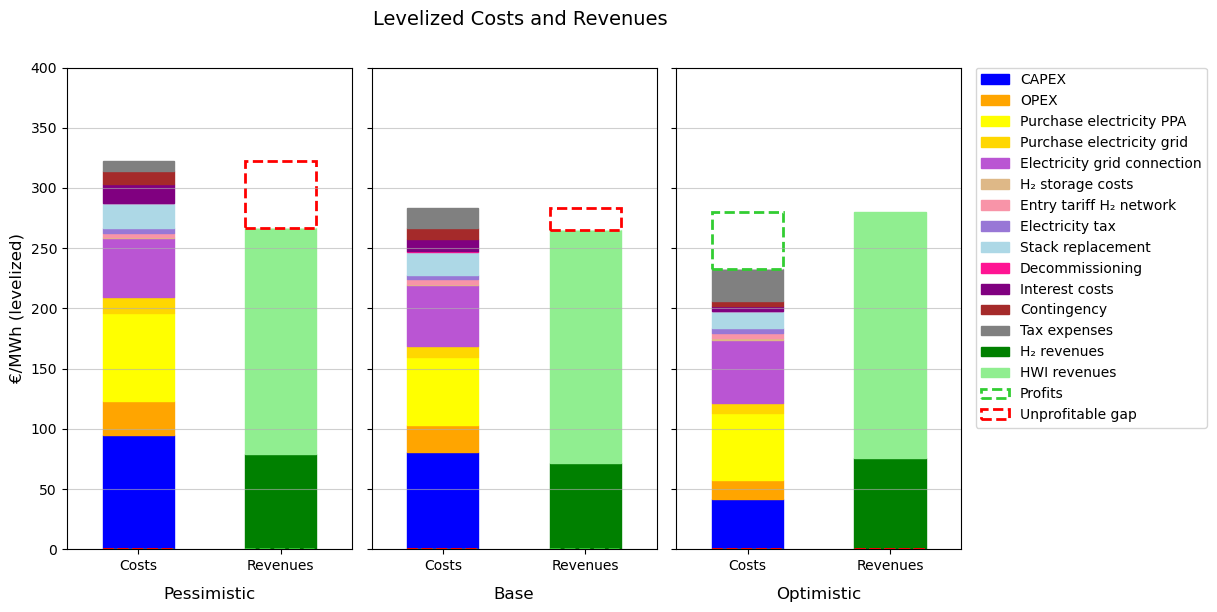

In [6]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, onel_module, onel_inputs, "onel_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')


Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


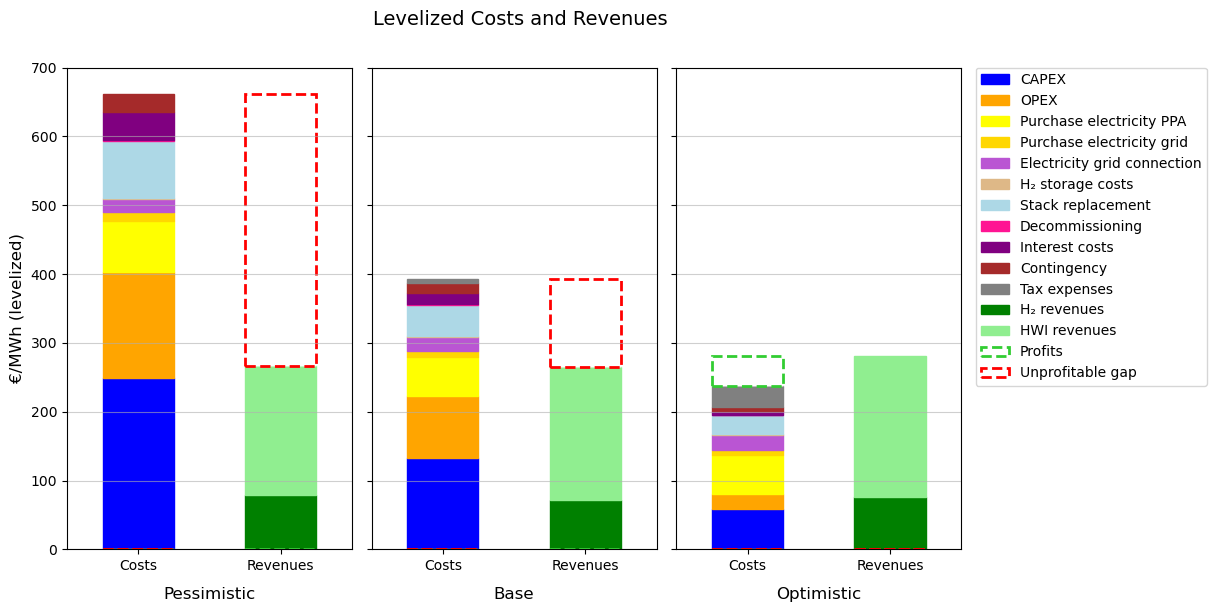

In [7]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, el_module, el_inputs, "el_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')

Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


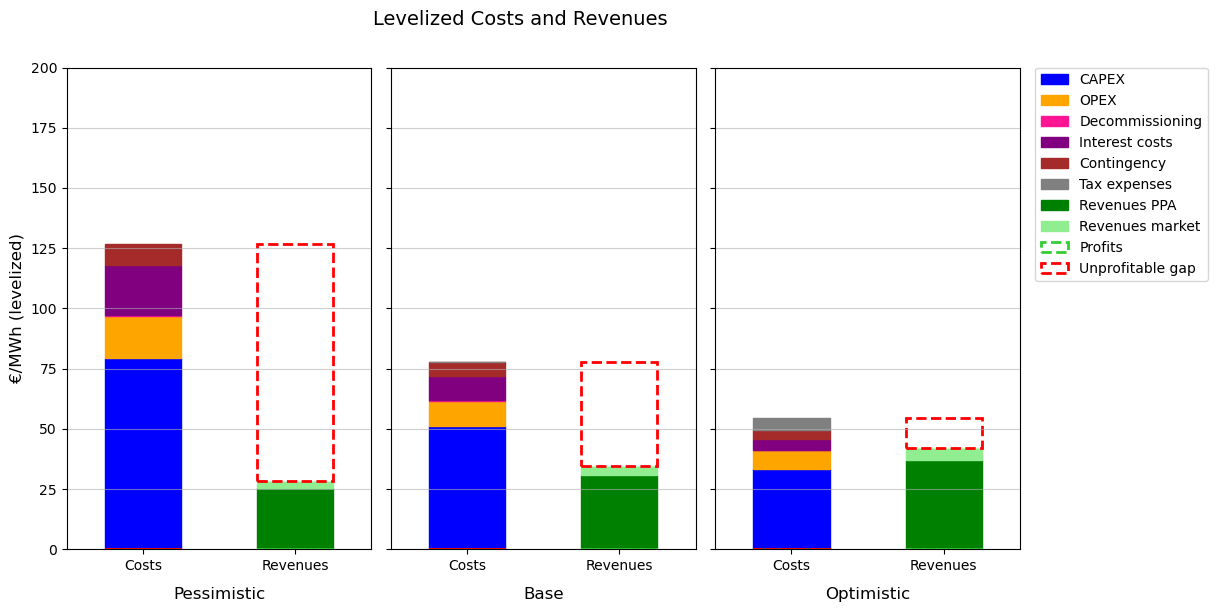

In [8]:
# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(runner, owf_module, owf_inputs, "owf_parameters")

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')